In [2]:
import sys

import ROOT
import numpy as np
import matplotlib.pylab as plt
import tqdm
%matplotlib inline

sys.path.append("../../../python")
from simhelper import util, root, parser
from simhelper import datatypes
from simhelper import helper_basic as hp
from simhelper import helper_plt as hplt

In [8]:
sim_data_dir = "/project/6075887/MATHUSLA/simulation/"


# Check simulation raw file
filename = f"{sim_data_dir}/cosmic/cosmic_all_sidewall/run_0.root"
tfile=ROOT.TFile(filename)
Tree = tfile.Get('metadata')
Tree.GetEntry(0)
print(Tree.GenReserved1)

In [10]:
file = root.tfile_reader(filename)
tree = file.get_tree("data")
entries = file.entries

In [11]:
keys = ["x","y","z", "px","py","pz", ]
data = {key:[] for key in keys}
for i in tqdm.tqdm(range(entries)):
    root_data = file.get_entry(i)
    data["x"].extend(root_data["Gen_x"])
    data["y"].extend(root_data["Gen_y"])
    data["z"].extend(root_data["Gen_z"])
    data["px"].extend(root_data["Gen_px"])
    data["py"].extend(root_data["Gen_py"])
    data["pz"].extend(root_data["Gen_pz"])    

for key in keys:
    data[key] = np.array(data[key])    

100%|██████████| 141657/141657 [00:18<00:00, 7706.33it/s]


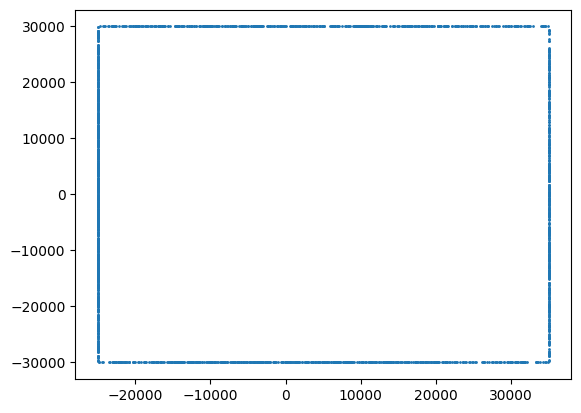

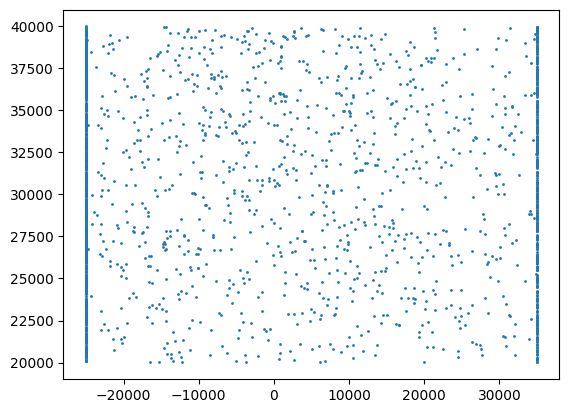

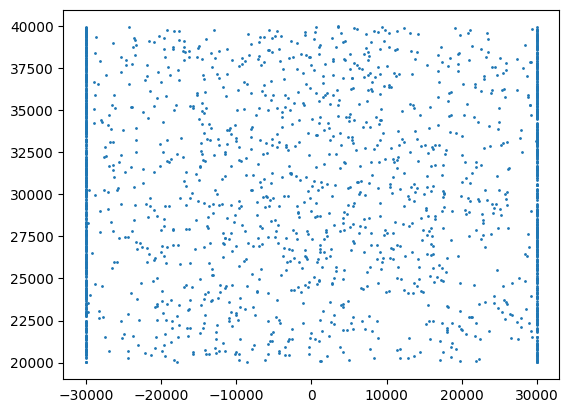

In [13]:
plt.scatter(data["x"][::100], data["y"][::100], s=1);
plt.show()

plt.scatter(data["x"][::100], data["z"][::100], s=1);
plt.show()

plt.scatter(data["y"][::100], data["z"][::100], s=1);
plt.show()